In [1]:
import pandas as pd
from pathlib import Path
from PIL import Image

df = pd.read_csv('/home/roman/tryondiffusion_implementation/tryondiffusion_danny/all_imgs_clean_80756_total.csv')
df.head(2)

,fullpath,ds,bad,item_idx,selector_toofew,pose_512,pose_is_none
0,/mnt/datadrive/asos_dataset/3602/1270/1117.png,3602,False,3602_1270,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False
1,/mnt/datadrive/asos_dataset/3602/1270/1118.png,3602,False,3602_1270,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False


In [2]:
from clothing_segmentation import HumanParser
human_parser = HumanParser()

back_path = '/mnt/datadrive/asos_dataset/3602/1270/1118.png'
no_back_path = '/mnt/datadrive/asos_dataset/3602/1270/1117.png'

/home/roman/venv_tryondiffusion_implementation/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


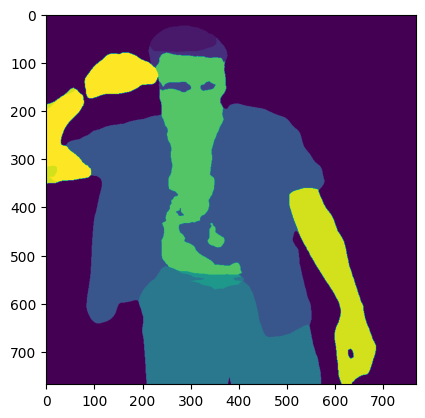

In [25]:
from matplotlib import pyplot as plt

back_image = Image.open(no_back_path).convert('RGB').resize((768, 768), Image.BICUBIC)
back_image_hp = human_parser.forward_img(back_image).cpu().squeeze(0)
plt.imshow(back_image_hp)


In [6]:
from transformers import CLIPProcessor, CLIPModel
import numpy as np


model_id = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_id)
model = CLIPModel.from_pretrained(model_id)
model.to('cuda')
clip_labels = ['front', 'back']
label_tokens = processor(
    text=clip_labels,
    padding=True,
    images=None,
    return_tensors='pt'
).to('cuda')
label_emb = model.get_text_features(**label_tokens)
# detach from pytorch gradient computation
label_emb = label_emb.detach().cpu().numpy()
label_emb = label_emb / np.linalg.norm(label_emb, axis=0)

def classify_image(imgpath, label_emb):
    clip_labels = ['front', 'back']
    image = Image.open(imgpath).convert('RGB').resize((768, 768), Image.BICUBIC)
    image = processor(
        text=None,
        images=image,
        return_tensors='pt'
    )['pixel_values'].to('cuda')
    img_emb = model.get_image_features(image)
    img_emb = img_emb.detach().cpu().numpy()
    img_emb = img_emb /  np.linalg.norm(img_emb, axis=0)
    img_emb.shape
    scores = np.dot(img_emb, label_emb.T)
    pred = np.argmax(scores)
    return pred


classify_image('/mnt/datadrive/asos_dataset/3602/1270/1118.png', label_emb)

1

In [8]:
df = pd.read_csv('/home/roman/tryondiffusion_implementation/tryondiffusion_danny/all_imgs_clean_80756_total.csv')
df.head(2)

,fullpath,ds,bad,item_idx,selector_toofew,pose_512,pose_is_none
0,/mnt/datadrive/asos_dataset/3602/1270/1117.png,3602,False,3602_1270,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False
1,/mnt/datadrive/asos_dataset/3602/1270/1118.png,3602,False,3602_1270,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False


In [15]:
from tqdm import tqdm

xxx = Path('/home/roman/tryondiffusion_implementation/tryondiffusion_danny/fdsdsfdsf')
xxx.mkdir(exist_ok=True, parents=True)
preds = []
for path in tqdm(df['fullpath'].values):
    try:
        pred = classify_image(path, label_emb)
    except Exception as e:
        pred = e
    preds.append(pred)

df['preds'] = preds
df.to_csv('preds.csv', index=False)

 56%|█████▋    | 45566/80761 [52:20<38:12, 15.35it/s]  /tmp/ipykernel_71391/373550920.py:31: RuntimeWarning: invalid value encountered in divide
  img_emb = img_emb /  np.linalg.norm(img_emb, axis=0)
100%|██████████| 80761/80761 [1:32:36<00:00, 14.53it/s]


In [19]:
fronts = df[df['preds']==0]
print(len(df))
print(len(fronts))

80761
38356


In [32]:
bad_items = {}
for k,v in fronts['item_idx'].value_counts().items():
    if v < 2:
        bad_items[k] = True
    else:
        bad_items[k] = False

In [35]:
fronts['bad_items'] = fronts['item_idx'].apply(lambda x: bad_items[x])

/tmp/ipykernel_71391/2472801820.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fronts['bad_items'] = fronts['item_idx'].apply(lambda x: bad_items[x])


In [37]:
fronts['bad_items'].value_counts()

bad_items
False    31126
True      7230
Name: count, dtype: int64

In [38]:
good_fronts = fronts[~fronts['bad_items']]
print(len(fronts))
print(len(good_fronts))

38356
31126


In [39]:
good_fronts.to_csv('good_fronts.csv', index=False)

In [5]:
import pandas as pd
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np
df = pd.read_csv('good_fronts.csv')
df.head()


,fullpath,ds,bad,item_idx,selector_toofew,pose_512,pose_is_none,preds,bad_items
0,/mnt/datadrive/asos_dataset/3602/1270/1117.png,3602,False,3602_1270,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False,0,False
1,/mnt/datadrive/asos_dataset/3602/1270/1119.png,3602,False,3602_1270,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False,0,False
2,/mnt/datadrive/asos_dataset/3602/1271/601.png,3602,False,3602_1271,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False,0,False
3,/mnt/datadrive/asos_dataset/3602/1272/4988.png,3602,False,3602_1272,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False,0,False
4,/mnt/datadrive/asos_dataset/3602/1272/4991.png,3602,False,3602_1272,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False,0,False


In [39]:
from transformers import CLIPProcessor, CLIPModel
import numpy as np


model_id = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_id)
model = CLIPModel.from_pretrained(model_id)
model.to('cuda')
clip_labels = ['arms and head', 'no arms and no head']
label_tokens = processor(
    text=clip_labels,
    padding=True,
    images=None,
    return_tensors='pt'
).to('cuda')
label_emb = model.get_text_features(**label_tokens)
# detach from pytorch gradient computation
label_emb = label_emb.detach().cpu().numpy()
label_emb = label_emb / np.linalg.norm(label_emb, axis=0)


In [40]:

def classify_image(imgpath, label_emb):
    image = Image.open(imgpath).convert('RGB').resize((768, 768), Image.BICUBIC)
    image = processor(
        text=None,
        images=image,
        return_tensors='pt'
    )['pixel_values'].to('cuda')
    img_emb = model.get_image_features(image)
    img_emb = img_emb.detach().cpu().numpy()
    img_emb = img_emb /  np.linalg.norm(img_emb, axis=0)
    img_emb.shape
    scores = np.dot(img_emb, label_emb.T)
    pred = np.argmax(scores)
    return pred

In [44]:
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image
import requests
import matplotlib.pyplot as plt
import torch.nn as nn

processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
model = AutoModelForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes")

# url = "https://plus.unsplash.com/premium_photo-1673210886161-bfcc40f54d1f?ixlib=rb-4.0.3&ixid=MnwxMjA3fDB8MHxzZWFyY2h8MXx8cGVyc29uJTIwc3RhbmRpbmd8ZW58MHx8MHx8&w=1000&q=80"


def gethp(imgpath):
    image = Image.open(imgpath)
    inputs = processor(images=image, return_tensors="pt")

    outputs = model(**inputs)
    logits = outputs.logits.cpu()

    upsampled_logits = nn.functional.interpolate(
        logits,
        size=image.size[::-1],
        mode="bilinear",
        align_corners=False,
    )

    pred_seg = upsampled_logits.argmax(dim=1)[0]
    return pred_seg

# plt.imshow(pred_seg.isin([2]))


/home/roman/venv_tryondiffusion_implementation/lib/python3.10/site-packages/transformers/models/segformer/image_processing_segformer.py:103: FutureWarning: The `reduce_labels` parameter is deprecated and will be removed in a future version. Please use `do_reduce_labels` instead.
  warnings.warn(


0
/mnt/datadrive/asos_dataset/3602/1270/1117.png


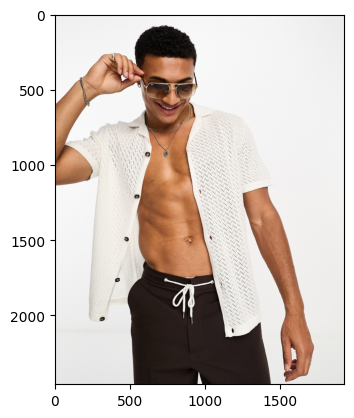

1
/mnt/datadrive/asos_dataset/3602/1270/1119.png


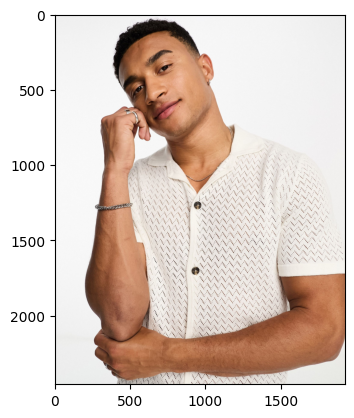

2
/mnt/datadrive/asos_dataset/3602/1271/601.png


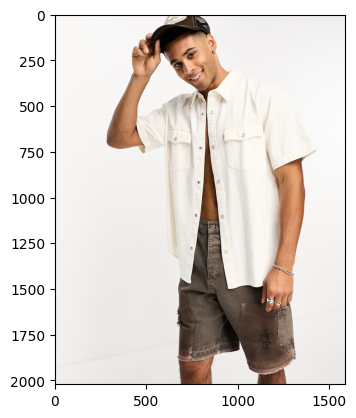

3
/mnt/datadrive/asos_dataset/3602/1272/4988.png


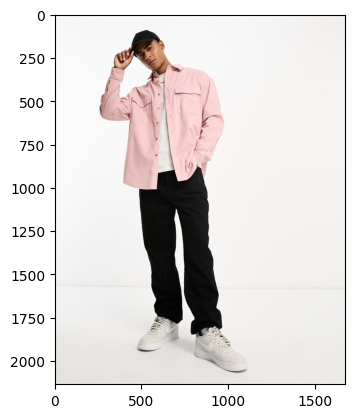

4
/mnt/datadrive/asos_dataset/3602/1272/4991.png


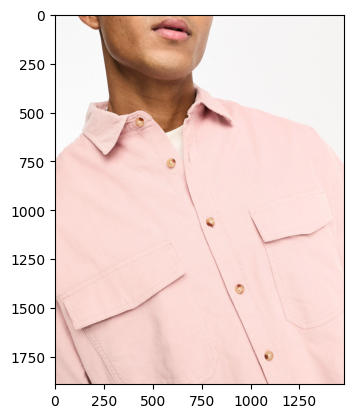

5
/mnt/datadrive/asos_dataset/3602/1273/4508.png


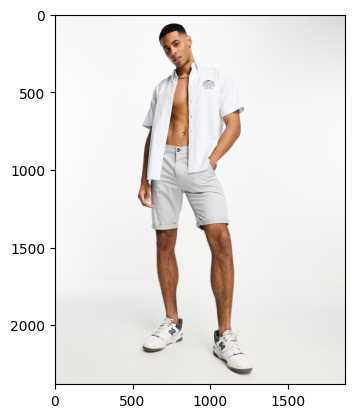

6
/mnt/datadrive/asos_dataset/3602/1273/4509.png


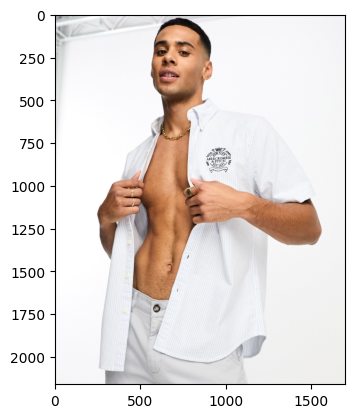

7
/mnt/datadrive/asos_dataset/3602/1273/4511.png


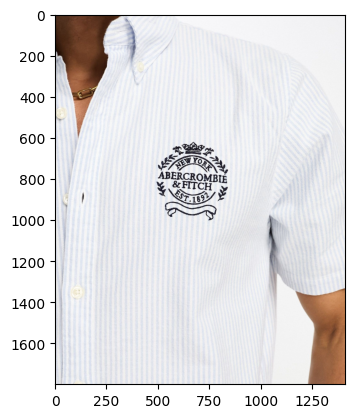

8
/mnt/datadrive/asos_dataset/3602/1275/6250.png


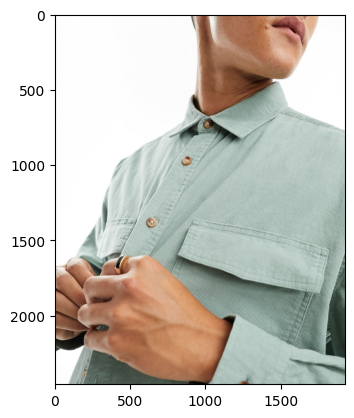

9
/mnt/datadrive/asos_dataset/3602/1275/6251.png


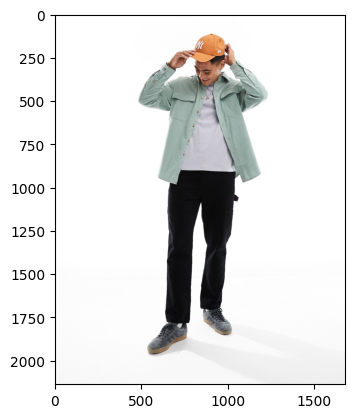

10
/mnt/datadrive/asos_dataset/3602/1276/4753.png


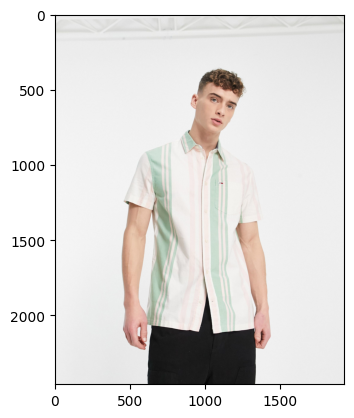

11
/mnt/datadrive/asos_dataset/3602/1276/4754.png


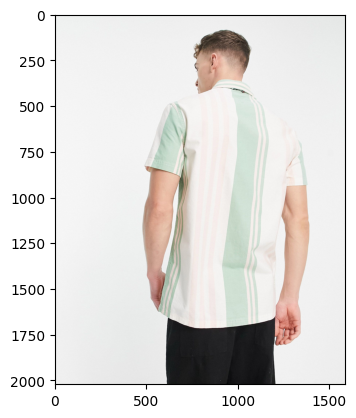

12
/mnt/datadrive/asos_dataset/3602/1276/4755.png


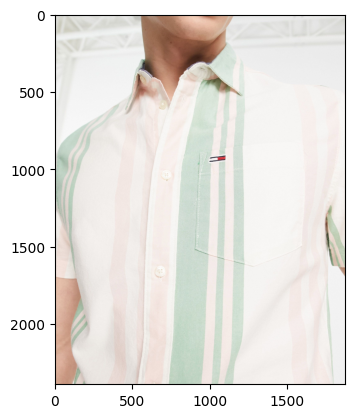

13
/mnt/datadrive/asos_dataset/3602/1277/1928.png


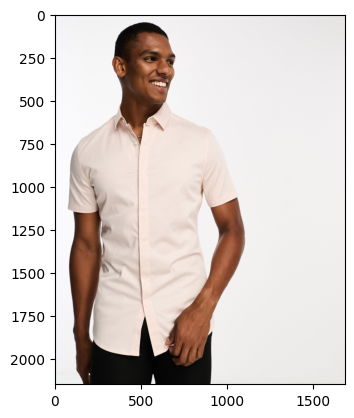

14
/mnt/datadrive/asos_dataset/3602/1277/1931.png


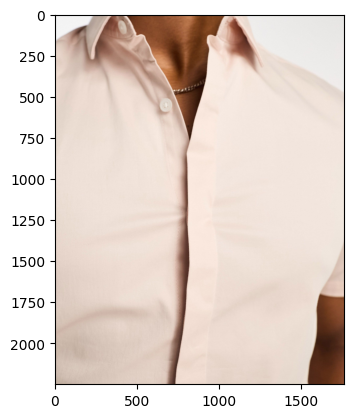

15
/mnt/datadrive/asos_dataset/3602/1281/5244.png


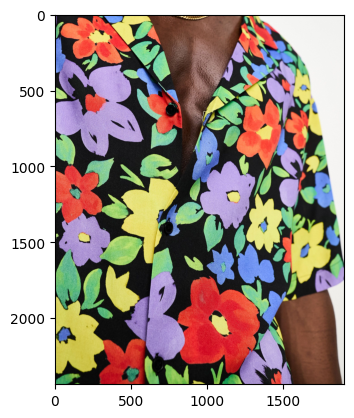

16
/mnt/datadrive/asos_dataset/3602/1281/5245.png


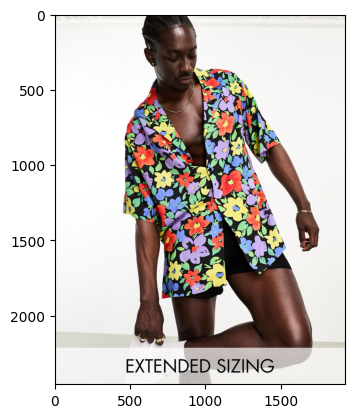

17
/mnt/datadrive/asos_dataset/3602/1286/1185.png


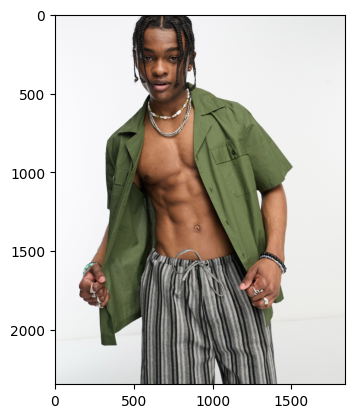

18
/mnt/datadrive/asos_dataset/3602/1286/1186.png


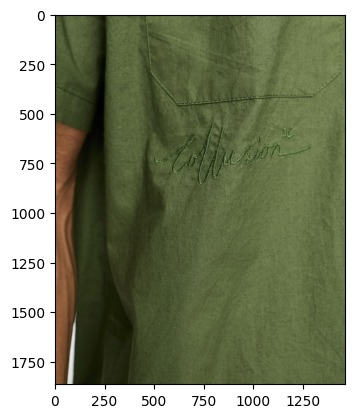

19
/mnt/datadrive/asos_dataset/3602/1286/1187.png


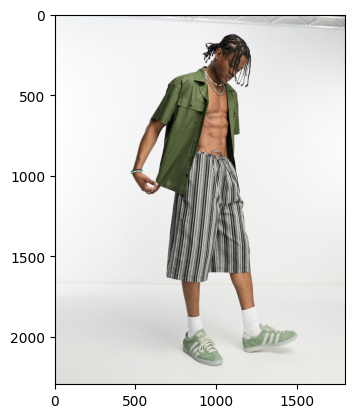

20
/mnt/datadrive/asos_dataset/3602/1287/2505.png


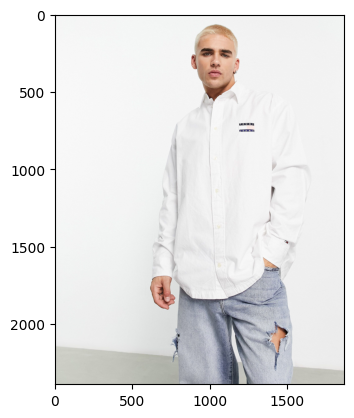

21
/mnt/datadrive/asos_dataset/3602/1287/2506.png


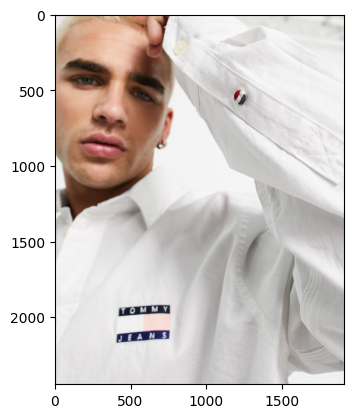

In [45]:

for idx, i in enumerate(df['fullpath'].values):
    img = np.array(Image.open(i))
    print(idx)
    # pred_seg = gethp(i)
    # ddd = np.unique(pred_seg)
    # if 15 in ddd and 14 in ddd and 11 in ddd:
        
    print(i)
    plt.imshow(img)
    plt.show()
    if idx > 20: 
        break


In [10]:
from tryondiffusion.dataset import MyOpenPoseDetector
from diffusers.utils import load_image
openpose = MyOpenPoseDetector.from_pretrained("lllyasviel/ControlNet")

/home/roman/venv_tryondiffusion_implementation/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/roman/venv_tryondiffusion_implementation/lib/python3.10/site-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(


In [50]:
from tqdm import tqdm

turbogood = []
for idx, i in tqdm(enumerate(df['fullpath'].values), total=len(df)):
    try:
        # img = np.array(Image.open(i))
        pred_seg = gethp(i)
        ddd = np.unique(pred_seg)
        if (15 in ddd or 14 in ddd) and 11 in ddd and 6 in ddd:
            turbogood.append(True)
            # print(True)
        else:
            turbogood.append(False)
            # print(False)
        # print(i)
        # plt.imshow(img)
        # plt.show()
        # if idx > 20: 
        #     break
    except Exception as e:
        turbogood.append(False)


df['turbogood'] = turbogood
df.to_csv('turbogood.csv', index=False)



100%|██████████| 31126/31126 [10:19:48<00:00,  1.19s/it] 


In [54]:
# for idx, (good, path) in enumerate(zip(df['turbogood'].values, df['fullpath'].values)):
#     print(good)
#     img = np.array(Image.open(path))
#     plt.imshow(img)
#     plt.show()

#     if idx > 20:
#         break

In [55]:
df['turbogood'].value_counts()

turbogood
True     20473
False    10653
Name: count, dtype: int64

In [56]:
turbogood_good = df[df['turbogood']]
len(turbogood_good)

20473

In [57]:
turbogood_good.to_csv('turbogood_good.csv', index=False)

In [76]:
good = {}
for k,v in turbogood_good['item_idx'].value_counts().items():
    if int(v)>int(1):
        good[k] = True

len(good)

7746

In [77]:
turbogood_good['selector_toofew'] = False

/tmp/ipykernel_237915/4065504839.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  turbogood_good['selector_toofew'] = False


In [78]:
turbogood_good['selector_toofew'] = turbogood_good['item_idx'].apply(lambda x: good.get(x, False))
turbogood_good['selector_toofew'].value_counts()

/tmp/ipykernel_237915/250905715.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  turbogood_good['selector_toofew'] = turbogood_good['item_idx'].apply(lambda x: good.get(x, False))


selector_toofew
True     16991
False     3482
Name: count, dtype: int64

In [79]:
turboturbogood = turbogood_good[turbogood_good['selector_toofew']]
len(turboturbogood)

16991

In [80]:
turboturbogood.to_csv('turboturbo.csv', index=False)